# Notebook 02: Data Preparation

All data transformation and preparation for multilevel modeling: loading, recoding, index creation, centering/standardization, merging, regime assignment, and export.

## Setup

In [1]:
# Standard imports only â€” no src/ module imports
import sys
import logging
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path (for config.py only)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pyreadstat

# Config only â€” everything else is inlined below
import config

# Logging
logger = logging.getLogger('ess_analysis')
logger.setLevel(logging.INFO)
logger.handlers = []
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s'))
logger.addHandler(handler)

# Display options
sns.set_theme(style='darkgrid', palette='Set2')
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

print(f"Project root: {project_root}")
print("Ready to prepare data for analysis!")

Project root: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis
Ready to prepare data for analysis!


## 1. Load Raw Data

In [2]:
# â”€â”€ Load ESS individual-level data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
filepath = config.ESS_FILE
countries = config.COUNTRIES

if not filepath.exists():
    raise FileNotFoundError(
        f"ESS data file not found: {filepath}\n"
        "Please download ESS9e03_3.dta from https://ess.sitehost.iu.edu/ "
        "and place it in data/raw/"
    )

logger.info(f"Loading ESS data from: {filepath}")
ess_df, meta = pyreadstat.read_dta(str(filepath))
logger.info(f"Loaded {len(ess_df):,} observations, {len(ess_df.columns)} variables")

# Filter to analysis countries
ess_df = ess_df[ess_df[config.COUNTRY_VAR].isin(countries)]
logger.info(f"Filtered to {len(countries)} countries, {len(ess_df):,} observations")

# Replace ESS missing value codes with NaN
for col in ess_df.select_dtypes(include=['number']).columns:
    for code_name, code_value in config.MISSING_CODES.items():
        ess_df.loc[ess_df[col] == code_value, col] = pd.NA

logger.info("Replaced ESS missing value codes with NaN")
print(f"\nESS data: {len(ess_df):,} observations, {len(ess_df.columns)} variables")

2026-03-06 16:42:27,255 - ess_analysis - INFO - Loading ESS data from: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis\data\raw\ESS9e03_3.dta


2026-03-06 16:42:33,189 - ess_analysis - INFO - Loaded 49,519 observations, 575 variables


2026-03-06 16:42:33,612 - ess_analysis - INFO - Filtered to 28 countries, 48,436 observations


2026-03-06 16:42:33,897 - ess_analysis - INFO - Replaced ESS missing value codes with NaN



ESS data: 48,436 observations, 575 variables


In [3]:
# â”€â”€ Load country-level economic data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
country_df = None

# Gini
if config.GINI_FILE.exists():
    gini_df = pd.read_csv(config.GINI_FILE)
    gini_df = gini_df.rename(columns={'value': 'gini'})
    if 'year' in gini_df.columns:
        gini_df = gini_df[gini_df['year'] == 2018]
    country_df = gini_df[['country', 'gini']]
    logger.info(f"Loaded Gini data for {len(country_df)} countries")
else:
    logger.warning(f"Gini data not found: {config.GINI_FILE}")

# GDP
if config.GDP_FILE.exists():
    gdp_df = pd.read_csv(config.GDP_FILE)
    gdp_df = gdp_df.rename(columns={'value': 'gdp'})
    if 'year' in gdp_df.columns:
        gdp_df = gdp_df[gdp_df['year'] == 2018]
    gdp_df = gdp_df[['country', 'gdp']]
    if country_df is not None:
        country_df = country_df.merge(gdp_df, on='country', how='outer')
    else:
        country_df = gdp_df
    logger.info(f"Loaded GDP data for {len(gdp_df)} countries")
else:
    logger.warning(f"GDP data not found: {config.GDP_FILE}")

# Unemployment
if config.UNEMPLOYMENT_FILE.exists():
    unemp_df = pd.read_csv(config.UNEMPLOYMENT_FILE)
    unemp_df = unemp_df.rename(columns={'value': 'unemployment'})
    if 'year' in unemp_df.columns:
        unemp_df = unemp_df[unemp_df['year'] == 2018]
    unemp_df = unemp_df[['country', 'unemployment']]
    if country_df is not None:
        country_df = country_df.merge(unemp_df, on='country', how='outer')
    else:
        country_df = unemp_df
    logger.info(f"Loaded unemployment data for {len(unemp_df)} countries")
else:
    logger.warning(f"Unemployment data not found: {config.UNEMPLOYMENT_FILE}")

if country_df is None:
    raise FileNotFoundError("No country-level data files found!")

country_df['country'] = country_df['country'].str.upper()
print(f"Country-level data: {len(country_df)} countries")
country_df.head()

2026-03-06 16:42:33,927 - ess_analysis - INFO - Loaded Gini data for 27 countries


2026-03-06 16:42:33,945 - ess_analysis - INFO - Loaded GDP data for 27 countries


2026-03-06 16:42:33,955 - ess_analysis - INFO - Loaded unemployment data for 28 countries


Country-level data: 28 countries


,country,gini,gdp,unemployment
0,AT,30.8,56636.495,4.933
1,BE,27.2,52466.733,5.941
2,BG,41.3,22605.866,5.211
3,CH,33.1,70688.819,4.713
4,CY,32.7,37927.168,8.504


In [4]:
# â”€â”€ Load institutional data (optional) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if config.INSTITUTIONAL_FILE.exists():
    institutional_df = pd.read_csv(config.INSTITUTIONAL_FILE)
    institutional_df['country'] = institutional_df['country'].str.upper()
    logger.info(f"Loaded institutional data for {len(institutional_df)} countries")
else:
    institutional_df = pd.DataFrame(columns=[
        'country', 'epl', 'almp_spending', 'union_density',
        'social_spending', 'collective_bargaining'
    ])
    logger.warning("Institutional data not found â€” extension analyses will be limited")

# â”€â”€ Load AI exposure data (optional) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if config.AI_EXPOSURE_FILE.exists():
    ai_df = pd.read_csv(config.AI_EXPOSURE_FILE)
    ai_df['country'] = ai_df['country'].str.upper()
    logger.info(f"Loaded AI exposure data for {len(ai_df)} countries")
else:
    ai_df = pd.DataFrame(columns=[
        'country', 'ai_exposure_oecd', 'automation_risk',
        'ai_exposure_felten', 'social_exposure'
    ])
    logger.warning("AI exposure data not found â€” AI extension analysis unavailable")

print(f"Institutional data: {len(institutional_df)} countries")
print(f"AI exposure data: {len(ai_df)} countries")

2026-03-06 16:42:33,987 - ess_analysis - INFO - Loaded institutional data for 28 countries


2026-03-06 16:42:33,991 - ess_analysis - INFO - Loaded AI exposure data for 28 countries


Institutional data: 28 countries
AI exposure data: 28 countries


## 2. Merge Datasets

In [5]:
# Merge ESS with country-level economic data
df = ess_df.merge(
    country_df,
    left_on=config.COUNTRY_VAR,
    right_on='country',
    how='left'
)

# Check for countries without country-level data
missing_country = df[df['country'].isna()][config.COUNTRY_VAR].unique()
if len(missing_country) > 0:
    logger.warning(f"Countries without country-level data: {missing_country.tolist()}")

logger.info(f"After country merge: {len(df):,} observations")

# Merge institutional data (if available)
if len(institutional_df) > 0:
    df = df.merge(
        institutional_df,
        left_on=config.COUNTRY_VAR,
        right_on='country',
        how='left',
        suffixes=('', '_inst')
    )
    logger.info("Merged institutional data")

# Merge AI exposure data (if available)
if len(ai_df) > 0:
    df = df.merge(
        ai_df,
        left_on=config.COUNTRY_VAR,
        right_on='country',
        how='left',
        suffixes=('', '_ai')
    )
    logger.info("Merged AI exposure data")

print(f"Merged dataset: {len(df):,} observations, {len(df.columns)} variables")

2026-03-06 16:42:34,238 - ess_analysis - INFO - After country merge: 48,436 observations


2026-03-06 16:42:35,189 - ess_analysis - INFO - Merged institutional data


2026-03-06 16:42:36,056 - ess_analysis - INFO - Merged AI exposure data


Merged dataset: 48,436 observations, 590 variables


## 3. Variable Transformations

In [6]:
# â”€â”€ 3a. Reverse code outcome variable â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# gincdif: 1=agree strongly ... 5=disagree strongly
# We want higher = more support for redistribution
outcome_var = config.OUTCOME_VAR  # 'gincdif'

if outcome_var in df.columns:
    df[config.OUTCOME_VAR_REVERSED] = (5 + 1) - df[outcome_var]  # reverse_code(series, max_val=5)
    logger.info(f"Reverse-coded '{outcome_var}' â†’ '{config.OUTCOME_VAR_REVERSED}'")
    print(f"redist_support: mean={df[config.OUTCOME_VAR_REVERSED].mean():.2f}, "
          f"sd={df[config.OUTCOME_VAR_REVERSED].std():.2f}")
else:
    raise ValueError(f"Outcome variable '{outcome_var}' not found!")

2026-03-06 16:42:36,080 - ess_analysis - INFO - Reverse-coded 'gincdif' â†’ 'redist_support'


redist_support: mean=3.90, sd=0.98


In [7]:
# â”€â”€ 3b. Create meritocracy index â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# ESS9 Justice & Fairness module:
#   sofrwrk: "Society is fair when hard-working people earn more" (1-5)
#   ppldsrv: "People get what they deserve" (1-5)
merit_effort_var = config.LEVEL1_VARS['merit_effort']   # 'sofrwrk'
merit_deserve_var = config.LEVEL1_VARS['merit_deserve']  # 'ppldsrv'

if merit_effort_var in df.columns and merit_deserve_var in df.columns:
    df['meritocracy'] = df[[merit_effort_var, merit_deserve_var]].mean(axis=1)
    n_complete = df['meritocracy'].notna().sum()
    logger.info(f"Created meritocracy index: mean={df['meritocracy'].mean():.2f}, n={n_complete:,}")
    print(f"Meritocracy index created from {merit_effort_var} + {merit_deserve_var}")
    print(f"  mean={df['meritocracy'].mean():.2f}, sd={df['meritocracy'].std():.2f}, n={n_complete:,}")
else:
    missing = [v for v in [merit_effort_var, merit_deserve_var] if v not in df.columns]
    logger.warning(f"Meritocracy variables not found: {missing}")
    print(f"WARNING: Meritocracy variables not found: {missing}")

2026-03-06 16:42:36,151 - ess_analysis - INFO - Created meritocracy index: mean=2.53, n=47,990


Meritocracy index created from sofrwrk + ppldsrv
  mean=2.53, sd=0.70, n=47,990


In [8]:
# â”€â”€ 3c. Create dummy variables â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Female dummy (gndr: 1=male, 2=female)
if 'gndr' in df.columns:
    df['female'] = (df['gndr'] == 2).astype(int)
    logger.info(f"Created 'female' dummy: {df['female'].sum():,} ({df['female'].mean()*100:.1f}%)")

# Employment dummy from pdwrk (paid work in last 7 days)
if 'pdwrk' in df.columns:
    df['employed'] = pd.to_numeric(df['pdwrk'], errors='coerce').eq(1).astype(int)
    logger.info(f"Created 'employed' dummy: {df['employed'].sum():,} ({df['employed'].mean()*100:.1f}%)")

print(f"Female: {df['female'].sum():,} ({df['female'].mean()*100:.1f}%)" if 'female' in df.columns else "female not created")
print(f"Employed: {df['employed'].sum():,} ({df['employed'].mean()*100:.1f}%)" if 'employed' in df.columns else "employed not created")

2026-03-06 16:42:36,191 - ess_analysis - INFO - Created 'female' dummy: 25,919 (53.5%)


2026-03-06 16:42:36,196 - ess_analysis - INFO - Created 'employed' dummy: 25,383 (52.4%)


Female: 25,919 (53.5%)
Employed: 25,383 (52.4%)


In [9]:
# â”€â”€ 3d. Aggregate political trust to Level-2 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if 'trstprl' in df.columns:
    df['political_trust_l2'] = df.groupby(config.COUNTRY_VAR)['trstprl'].transform('mean')
    logger.info("Aggregated political trust to country level (political_trust_l2)")
    print(f"Political trust L2: mean={df['political_trust_l2'].mean():.2f}")

2026-03-06 16:42:36,235 - ess_analysis - INFO - Aggregated political trust to country level (political_trust_l2)


Political trust L2: mean=4.54


## 4. Centering and Standardization

In [10]:
# â”€â”€ 4a. Grand-mean center Level-1 variables â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
level1_to_center = ['hinctnta', 'trstprl', 'agea', 'eduyrs', 'meritocracy']
level1_to_center = [v for v in level1_to_center if v in df.columns]

print("Grand-mean centering Level-1 variables:")
for var in level1_to_center:
    # Ensure numeric before centering
    df[var] = pd.to_numeric(df[var], errors='coerce')
    grand_mean = df[var].mean()
    df[f'{var}_c'] = df[var] - grand_mean
    logger.info(f"Centered '{var}' (mean={grand_mean:.2f}) â†’ '{var}_c'")
    print(f"  {var}: grand mean = {grand_mean:.2f}")

print("\nVerification (centered means, should be â‰ˆ 0):")
centered_vars = [f'{v}_c' for v in level1_to_center]
print(df[centered_vars].apply(pd.to_numeric, errors='coerce').mean().round(8))

Grand-mean centering Level-1 variables:


2026-03-06 16:42:36,277 - ess_analysis - INFO - Centered 'hinctnta' (mean=5.24) â†’ 'hinctnta_c'


  hinctnta: grand mean = 5.24


2026-03-06 16:42:36,298 - ess_analysis - INFO - Centered 'trstprl' (mean=4.54) â†’ 'trstprl_c'


  trstprl: grand mean = 4.54


2026-03-06 16:42:36,321 - ess_analysis - INFO - Centered 'agea' (mean=50.98) â†’ 'agea_c'


  agea: grand mean = 50.98
2026-03-06 16:42:36,343 - ess_analysis - INFO - Centered 'eduyrs' (mean=12.97) â†’ 'eduyrs_c'


  eduyrs: grand mean = 12.97


2026-03-06 16:42:36,361 - ess_analysis - INFO - Centered 'meritocracy' (mean=2.53) â†’ 'meritocracy_c'


  meritocracy: grand mean = 2.53

Verification (centered means, should be â‰ˆ 0):
hinctnta_c       0.0
trstprl_c       -0.0
agea_c          -0.0
eduyrs_c         0.0
meritocracy_c   -0.0
dtype: float64


In [11]:
# â”€â”€ 4b. Z-score standardize Level-2 variables â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
level2_to_standardize = ['gini', 'gdp', 'unemployment']

# Add institutional variables if available
if 'epl' in df.columns:
    level2_to_standardize.extend(['epl', 'almp_spending', 'union_density', 'social_spending'])
# Add AI variables if available
if 'ai_exposure_oecd' in df.columns:
    level2_to_standardize.append('ai_exposure_oecd')
if 'automation_risk' in df.columns:
    level2_to_standardize.append('automation_risk')

level2_to_standardize = [v for v in level2_to_standardize if v in df.columns]

print("Z-score standardizing Level-2 variables:")
for var in level2_to_standardize:
    mean_val = df[var].mean()
    std_val = df[var].std()
    if std_val == 0:
        logger.warning(f"'{var}' has zero variance, skipping")
        continue
    df[f'{var}_z'] = (df[var] - mean_val) / std_val
    logger.info(f"Standardized '{var}' (mean={mean_val:.2f}, sd={std_val:.2f}) â†’ '{var}_z'")
    print(f"  {var}: mean={mean_val:.2f}, sd={std_val:.2f}")

print("\nVerification (country-level means and SDs of z-scores):")
z_vars = [f'{v}_z' for v in level2_to_standardize if f'{v}_z' in df.columns]
country_z = df.groupby(config.COUNTRY_VAR)[z_vars].first()
print(pd.DataFrame({'mean': country_z.mean(), 'std': country_z.std()}).round(3))

Z-score standardizing Level-2 variables:
2026-03-06 16:42:36,391 - ess_analysis - INFO - Standardized 'gini' (mean=31.52, sd=3.91) â†’ 'gini_z'


  gini: mean=31.52, sd=3.91
2026-03-06 16:42:36,396 - ess_analysis - INFO - Standardized 'gdp' (mean=45558.50, sd=16480.67) â†’ 'gdp_z'


  gdp: mean=45558.50, sd=16480.67
2026-03-06 16:42:36,400 - ess_analysis - INFO - Standardized 'unemployment' (mean=6.49, sd=3.30) â†’ 'unemployment_z'


  unemployment: mean=6.49, sd=3.30
2026-03-06 16:42:36,404 - ess_analysis - INFO - Standardized 'epl' (mean=2.35, sd=0.47) â†’ 'epl_z'


  epl: mean=2.35, sd=0.47
2026-03-06 16:42:36,408 - ess_analysis - INFO - Standardized 'almp_spending' (mean=0.54, sd=0.36) â†’ 'almp_spending_z'


  almp_spending: mean=0.54, sd=0.36
2026-03-06 16:42:36,411 - ess_analysis - INFO - Standardized 'union_density' (mean=26.08, sd=19.11) â†’ 'union_density_z'


  union_density: mean=26.08, sd=19.11
2026-03-06 16:42:36,416 - ess_analysis - INFO - Standardized 'social_spending' (mean=21.74, sd=4.99) â†’ 'social_spending_z'


  social_spending: mean=21.74, sd=4.99
2026-03-06 16:42:36,421 - ess_analysis - INFO - Standardized 'ai_exposure_oecd' (mean=0.09, sd=0.20) â†’ 'ai_exposure_oecd_z'


  ai_exposure_oecd: mean=0.09, sd=0.20
2026-03-06 16:42:36,425 - ess_analysis - INFO - Standardized 'automation_risk' (mean=0.34, sd=0.05) â†’ 'automation_risk_z'


  automation_risk: mean=0.34, sd=0.05

Verification (country-level means and SDs of z-scores):
                     mean    std
gini_z             -0.035  1.006
gdp_z              -0.041  0.995
unemployment_z      0.020  1.031
epl_z              -0.009  0.962
almp_spending_z    -0.005  1.075
union_density_z     0.098  1.137
social_spending_z  -0.070  0.988
ai_exposure_oecd_z -0.044  1.096
automation_risk_z  -0.057  1.050


## 5. Assign Welfare Regimes

In [12]:
# Esping-Andersen classification
df['welfare_regime'] = df[config.COUNTRY_VAR].map(config.COUNTRY_TO_REGIME_ESPING)
n_assigned = df['welfare_regime'].notna().sum()
logger.info(f"Esping-Andersen: assigned {n_assigned:,}/{len(df):,} observations")

# Varieties of Capitalism classification
df['voc_regime'] = df[config.COUNTRY_VAR].map(config.COUNTRY_TO_REGIME_VOC)

print("Esping-Andersen regime distribution:")
print(df['welfare_regime'].value_counts())
print(f"\nVoC regime distribution:")
print(df['voc_regime'].value_counts())

2026-03-06 16:42:36,472 - ess_analysis - INFO - Esping-Andersen: assigned 47,575/48,436 observations


Esping-Andersen regime distribution:
welfare_regime
Post-Communist              18785
Conservative/Corporatist    11849
Social Democratic            6272
Mediterranean                6249
Liberal                      4420
Name: count, dtype: int64

VoC regime distribution:
voc_regime
Dependent Market Economies (DME)        18785
Coordinated Market Economies (CME)      16111
Mediterranean Market Economies (MME)     8259
Liberal Market Economies (LME)           4420
Name: count, dtype: int64


## 6. Rename and Finalize

In [13]:
# Drop redundant merge-key columns
drop_cols = [c for c in ['country', 'country_inst', 'country_ai'] if c in df.columns]
df = df.drop(columns=drop_cols)

# Rename raw ESS variable names to friendly names
rename_map = {
    'cntry': 'country',
    'hinctnta': 'income', 'hinctnta_c': 'income_c',
    'eduyrs': 'education', 'eduyrs_c': 'education_c',
    'agea': 'age', 'agea_c': 'age_c',
    'trstprl': 'political_trust', 'trstprl_c': 'political_trust_c',
    'gndr': 'gender',
    'lrscale': 'ideology',
    'meritocracy': 'meritocracy_index', 'meritocracy_c': 'meritocracy_index_c',
    'gdp': 'gdp_per_capita', 'gdp_z': 'gdp_per_capita_z',
    'unemployment': 'unemployment_rate', 'unemployment_z': 'unemployment_rate_z',
    'welfare_regime': 'regime_esping',
    'voc_regime': 'regime_voc',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Ensure numeric types for key variables
numeric_cols = [c for c in df.columns if c.endswith('_c') or c.endswith('_z') 
                or c in ['income', 'education', 'age', 'ideology', 'political_trust',
                         'redist_support', 'female', 'employed', 'gini', 'gdp_per_capita', 
                         'unemployment_rate', 'meritocracy_index']]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Center ideology manually (not in default pipeline)
if 'ideology' in df.columns:
    df['ideology_c'] = df['ideology'] - df['ideology'].mean()

print(f"Analysis dataset created!")
print(f"  - Observations: {len(df):,}")
print(f"  - Variables: {len(df.columns)}")
print(f"  - Countries: {df['country'].nunique()}")
if 'employed' in df.columns:
    print(f"  - Employed: {df['employed'].sum():,} ({df['employed'].mean()*100:.1f}%)")

Analysis dataset created!
  - Observations: 48,436
  - Variables: 609
  - Countries: 28
  - Employed: 25,383 (52.4%)


In [14]:
# Display first rows
df.head(10)

,name,essround,edition,proddate,idno,country,dweight,pspwght,pweight,anweight,nwspol,netusoft,netustm,ppltrst,pplfair,pplhlp,polintr,psppsgva,actrolga,psppipla,cptppola,political_trust,trstlgl,trstplc,trstplt,...,automation_risk,ai_exposure_felten,social_exposure,redist_support,meritocracy_index,female,employed,political_trust_l2,income_c,political_trust_c,age_c,education_c,meritocracy_index_c,gini_z,gdp_per_capita_z,unemployment_rate_z,epl_z,almp_spending_z,union_density_z,social_spending_z,ai_exposure_oecd_z,automation_risk_z,regime_esping,regime_voc,ideology_c
0,ESS9e03_3,NaN,3.3,26.01.2026,27.0,AT,0.581,0.218,0.302,0.066,60,5,180,2,2,2,3,3,2,2,2,5.0,10,10,5,...,0.34,0.35,NaN,5.0,2.0,0,1,5.42,-2.237,0.458,-7.977,-0.968,-0.526,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),3.968
1,ESS9e03_3,NaN,3.3,26.01.2026,137.0,AT,1.063,0.413,0.302,0.125,10,5,20,7,8,7,2,3,2,3,2,7.0,8,8,3,...,0.34,0.35,NaN,4.0,1.5,0,0,5.42,-0.237,2.458,16.023,-0.968,-1.026,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-0.032
2,ESS9e03_3,NaN,3.3,26.01.2026,194.0,AT,1.377,2.270,0.302,0.686,60,4,180,5,7,7,4,2,1,3,2,6.0,8,8,5,...,0.34,0.35,NaN,4.0,2.5,1,1,5.42,3.763,1.458,-10.977,-0.968,-0.026,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-0.032
3,ESS9e03_3,NaN,3.3,26.01.2026,208.0,AT,0.993,0.386,0.302,0.117,45,5,120,3,9,5,3,2,2,3,1,0.0,5,8,3,...,0.34,0.35,NaN,4.0,2.5,0,1,5.42,0.763,-4.542,12.023,-1.968,-0.026,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),NaN
4,ESS9e03_3,NaN,3.3,26.01.2026,220.0,AT,0.377,1.032,0.302,0.312,30,1,NaN,5,8,4,2,1,1,1,3,7.0,8,8,7,...,0.34,0.35,NaN,4.0,2.5,1,0,5.42,-4.237,2.458,20.023,-4.968,-0.026,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-0.032
5,ESS9e03_3,NaN,3.3,26.01.2026,254.0,AT,1.479,0.576,0.302,0.174,45,2,NaN,8,7,6,2,2,2,3,2,6.0,5,7,5,...,0.34,0.35,NaN,4.0,2.0,0,0,5.42,-0.237,1.458,13.023,0.032,-0.526,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-2.032
6,ESS9e03_3,NaN,3.3,26.01.2026,290.0,AT,0.992,0.721,0.302,0.218,60,1,NaN,6,1,3,4,2,2,3,2,0.0,5,5,0,...,0.34,0.35,NaN,5.0,2.0,0,1,5.42,1.763,-4.542,5.023,-0.968,-0.526,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-2.032
7,ESS9e03_3,NaN,3.3,26.01.2026,301.0,AT,0.310,0.130,0.302,0.039,30,1,NaN,7,7,7,3,1,1,1,2,5.0,7,7,3,...,0.34,0.35,NaN,4.0,3.5,1,0,5.42,-3.237,0.458,23.023,-1.968,0.974,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),1.968
8,ESS9e03_3,NaN,3.3,26.01.2026,305.0,AT,1.230,1.771,0.302,0.535,30,5,120,2,9,9,3,1,1,1,4,1.0,10,10,1,...,0.34,0.35,NaN,5.0,2.0,0,1,5.42,NaN,-3.542,-13.977,-0.968,-0.526,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-1.032
9,ESS9e03_3,NaN,3.3,26.01.2026,400.0,AT,0.459,0.743,0.302,0.224,25,4,360,7,4,4,4,2,2,2,1,3.0,5,5,4,...,0.34,0.35,NaN,4.0,2.0,1,0,5.42,-2.237,-1.542,-28.977,-0.968,-0.526,-0.184,0.672,-0.472,0.194,0.154,0.011,0.974,-0.383,-0.079,Conservative/Corporatist,Coordinated Market Economies (CME),-0.032


In [15]:
# Variable list
print("Variables in analysis dataset:")
print("\nLevel-1 (Individual):")
level1_vars = [col for col in df.columns if col.endswith('_c') or col in 
               ['redist_support', 'female', 'employed', 'country']]
print(sorted(level1_vars))

print("\nLevel-2 (Country):")
level2_vars = [col for col in df.columns if col.endswith('_z') or col in 
               ['regime_esping', 'regime_voc']]
print(sorted(level2_vars))

Variables in analysis dataset:

Level-1 (Individual):
['age_c', 'country', 'education_c', 'employed', 'female', 'ideology_c', 'income_c', 'meritocracy_index_c', 'political_trust_c', 'redist_support']

Level-2 (Country):
['ai_exposure_oecd_z', 'almp_spending_z', 'automation_risk_z', 'epl_z', 'gdp_per_capita_z', 'gini_z', 'regime_esping', 'regime_voc', 'social_spending_z', 'unemployment_rate_z', 'union_density_z']


## 7. Verify Transformations

In [16]:
# Check centering (Level-1 variables should have mean â‰ˆ 0)
centered_vars = [col for col in df.columns if col.endswith('_c')]

print("Centered variables (should have mean â‰ˆ 0):")
centering_check = df[centered_vars].mean()
print(centering_check.round(6))

if all(abs(centering_check) < 1e-10):
    print("\nâœ“ Centering successful!")
else:
    print("\nâš  Warning: Some variables not properly centered")

Centered variables (should have mean â‰ˆ 0):
income_c               0.0
political_trust_c     -0.0
age_c                 -0.0
education_c            0.0
meritocracy_index_c   -0.0
ideology_c             0.0
dtype: float64

âœ“ Centering successful!


In [17]:
# Check standardization (Level-2 variables should have mean â‰ˆ 0, SD â‰ˆ 1)
standardized_vars = [col for col in df.columns if col.endswith('_z')]

print("Standardized variables (should have mean â‰ˆ 0, SD â‰ˆ 1):")
# Aggregate by country first (these are country-level vars)
country_std_df = df.groupby('country')[standardized_vars].first()

std_check = pd.DataFrame({
    'mean': country_std_df.mean(),
    'std': country_std_df.std()
})
print(std_check.round(3))

if len(std_check) > 0 and all(abs(std_check['mean']) < 0.1):
    print("\nâœ“ Standardization successful!")
else:
    print("\nâš  Warning: Check standardization results above")

Standardized variables (should have mean â‰ˆ 0, SD â‰ˆ 1):
                      mean    std
gini_z              -0.035  1.006
gdp_per_capita_z    -0.041  0.995
unemployment_rate_z  0.020  1.031
epl_z               -0.009  0.962
almp_spending_z     -0.005  1.075
union_density_z      0.098  1.137
social_spending_z   -0.070  0.988
ai_exposure_oecd_z  -0.044  1.096
automation_risk_z   -0.057  1.050

âœ“ Standardization successful!


## 8. Welfare Regime Distributions

Esping-Andersen Welfare Regime Distribution:
regime_esping
Post-Communist              18785
Conservative/Corporatist    11849
Social Democratic            6272
Mediterranean                6249
Liberal                      4420
Name: count, dtype: int64

Total countries: 28


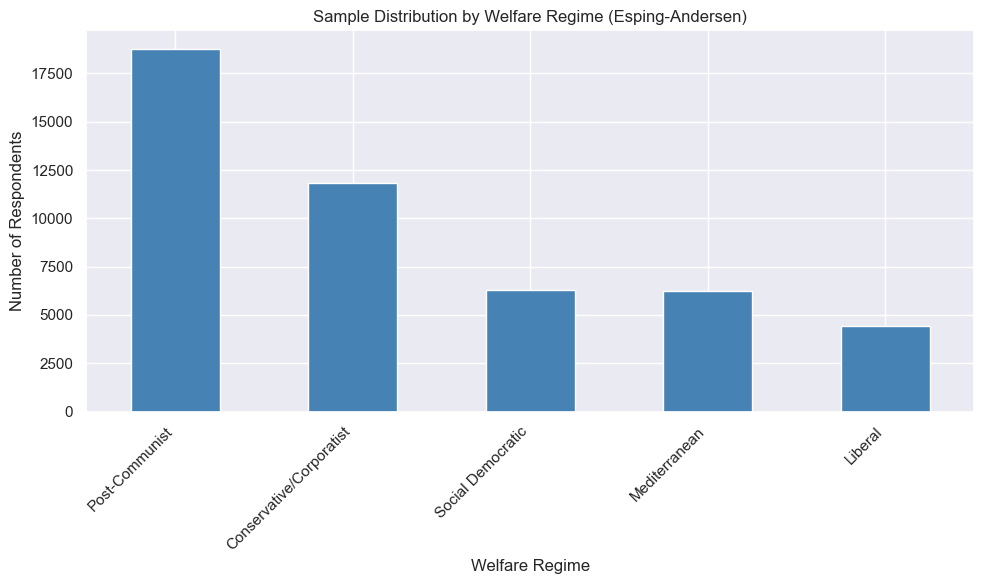

In [18]:
# Esping-Andersen regime distribution
regime_counts = df['regime_esping'].value_counts()

print("Esping-Andersen Welfare Regime Distribution:")
print(regime_counts)
print(f"\nTotal countries: {df['country'].nunique()}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
regime_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Welfare Regime')
ax.set_ylabel('Number of Respondents')
ax.set_title('Sample Distribution by Welfare Regime (Esping-Andersen)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Countries by regime
regime_countries = df.groupby('regime_esping')['country'].unique()

print("Countries by Esping-Andersen regime:")
for regime, countries in regime_countries.items():
    print(f"\n{regime}:")
    print(f"  {', '.join(sorted(countries))}")

Countries by Esping-Andersen regime:

Conservative/Corporatist:
  AT, BE, CH, DE, FR, NL

Liberal:
  GB, IE

Mediterranean:
  CY, ES, IT, PT

Post-Communist:
  BG, CZ, EE, HR, HU, LT, LV, ME, PL, RS, SI

Social Democratic:
  DK, FI, NO, SE


In [20]:
# Varieties of Capitalism distribution
voc_counts = df['regime_voc'].value_counts()

print("Varieties of Capitalism Distribution:")
print(voc_counts)

# Countries by VoC type
voc_countries = df.groupby('regime_voc')['country'].unique()

print("\nCountries by VoC type:")
for voc_type, countries in voc_countries.items():
    print(f"\n{voc_type}:")
    print(f"  {', '.join(sorted(countries))}")

Varieties of Capitalism Distribution:
regime_voc
Dependent Market Economies (DME)        18785
Coordinated Market Economies (CME)      16111
Mediterranean Market Economies (MME)     8259
Liberal Market Economies (LME)           4420
Name: count, dtype: int64

Countries by VoC type:

Coordinated Market Economies (CME):
  AT, BE, CH, DE, DK, FI, NL, NO, SE

Dependent Market Economies (DME):
  BG, CZ, EE, HR, HU, LT, LV, ME, PL, RS, SI

Liberal Market Economies (LME):
  GB, IE

Mediterranean Market Economies (MME):
  CY, ES, FR, IT, PT


## 9. Redistribution Support by Regime

In [21]:
# Mean redistribution support by Esping-Andersen regime
regime_means = df.groupby('regime_esping')['redist_support'].agg(['mean', 'std', 'count'])
regime_means = regime_means.sort_values('mean', ascending=False)

print("Redistribution support by welfare regime:")
print(regime_means.round(3))

Redistribution support by welfare regime:
                           mean    std  count
regime_esping                                
Mediterranean             4.114  0.828   6125
Post-Communist            3.974  0.968  18308
Conservative/Corporatist  3.836  1.016  11692
Liberal                   3.760  0.974   4363
Social Democratic         3.640  1.036   6176


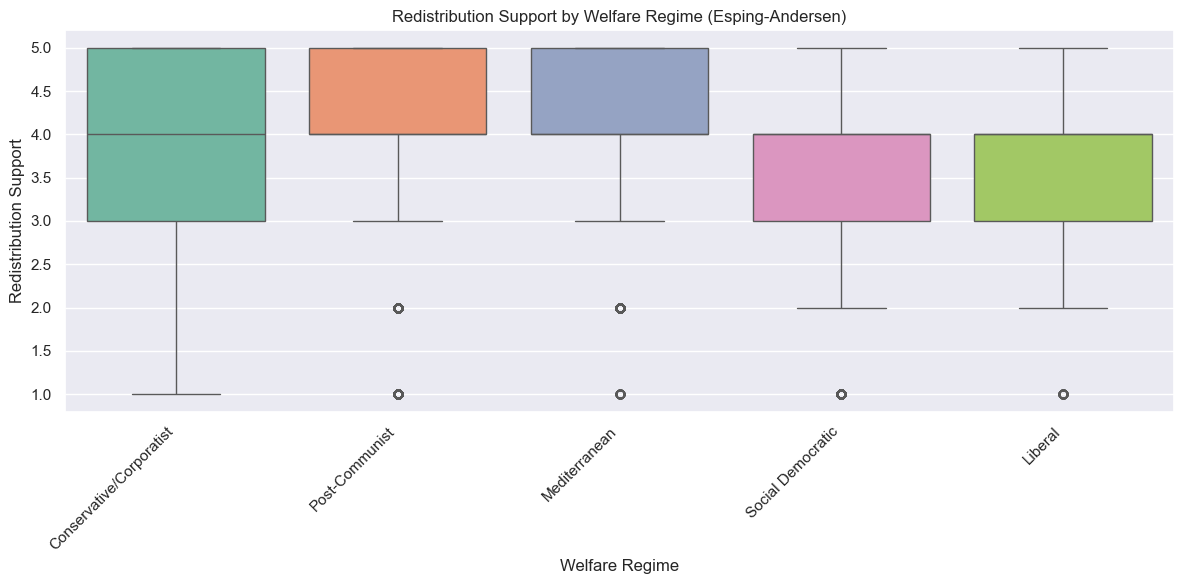

In [22]:
# Visualize redistribution support by regime
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = df[df['regime_esping'].notna()]
sns.boxplot(data=plot_data, x='regime_esping', y='redist_support', 
            palette='Set2', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Welfare Regime')
ax.set_ylabel('Redistribution Support')
ax.set_title('Redistribution Support by Welfare Regime (Esping-Andersen)')
plt.tight_layout()
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PLOTS_DIR / '02_regime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# ANOVA: Do regimes differ significantly?
# Prepare groups
regime_groups = [group['redist_support'].dropna() 
                 for name, group in df.groupby('regime_esping')]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*regime_groups)

print(f"One-way ANOVA:")
print(f"  F-statistic: {f_stat:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.001:
    print("  Result: Regimes differ significantly (p < 0.001)")
elif p_value < 0.05:
    print("  Result: Regimes differ significantly (p < 0.05)")
else:
    print("  Result: No significant differences between regimes")

One-way ANOVA:
  F-statistic: 246.179
  p-value: 0.0000
  Result: Regimes differ significantly (p < 0.001)


## 10. Missing Data After Transformations

In [24]:
# Check missing data in key variables
key_vars = ['redist_support', 'income_c', 'education_c', 'age_c', 
            'employed', 'ideology_c', 'political_trust_c', 'meritocracy_index_c',
            'female']
key_vars = [v for v in key_vars if v in df.columns]

# Inline missing data check
missing_report = []
for var in key_vars:
    n_missing = df[var].isna().sum()
    pct_missing = n_missing / len(df)
    missing_report.append({
        'variable': var,
        'n_missing': n_missing,
        'pct_missing': f'{pct_missing:.1%}',
        'above_5pct': pct_missing > 0.05
    })

missing_df = pd.DataFrame(missing_report)
print("Missing data after transformations:")
print(missing_df.to_string(index=False))

Missing data after transformations:
           variable  n_missing pct_missing  above_5pct
     redist_support        919        1.9%       False
           income_c       9408       19.4%        True
        education_c        689        1.4%       False
              age_c        210        0.4%       False
           employed          0        0.0%       False
         ideology_c       7145       14.8%        True
  political_trust_c       1133        2.3%       False
meritocracy_index_c        446        0.9%       False
             female          0        0.0%       False


In [25]:
# Complete cases analysis
n_total = len(df)
df_complete = df[key_vars].dropna()
n_complete = len(df_complete)

print(f"Complete cases analysis:")
print(f"  Total observations: {n_total:,}")
print(f"  Complete cases: {n_complete:,}")
print(f"  Dropped: {n_total - n_complete:,} ({(n_total - n_complete) / n_total * 100:.1f}%)")
print(f"\nRetention rate: {n_complete / n_total * 100:.1f}%")

Complete cases analysis:
  Total observations: 48,436
  Complete cases: 33,442
  Dropped: 14,994 (31.0%)

Retention rate: 69.0%


## 11. Descriptive Statistics (Transformed Variables)

In [26]:
# Level-1 variables (centered)
level1_continuous = ['income_c', 'education_c', 'age_c', 'ideology_c', 
                     'political_trust_c', 'meritocracy_index_c']
level1_continuous = [v for v in level1_continuous if v in df.columns]

print("Descriptive statistics - Level-1 variables (centered):")
print(df[level1_continuous].describe().round(3))

Descriptive statistics - Level-1 variables (centered):
        income_c  education_c      age_c  ideology_c  political_trust_c  \
count  39028.000    47747.000  48226.000   41291.000          47303.000   
mean       0.000        0.000     -0.000       0.000             -0.000   
std        2.781        4.184     18.672       2.255              2.658   
min       -4.237      -12.968    -35.977      -5.032             -4.542   
25%       -2.237       -1.968    -14.977      -1.032             -1.542   
50%       -0.237       -0.968      1.023      -0.032              0.458   
75%        2.763        3.032     15.023       0.968              2.458   
max        4.763       47.032     39.023       4.968              5.458   

       meritocracy_index_c  
count            47990.000  
mean                -0.000  
std                  0.702  
min                 -1.526  
25%                 -0.526  
50%                 -0.026  
75%                  0.474  
max                  2.474  


In [27]:
# Level-2 variables (standardized)
level2_std_vars = ['gini_z', 'gdp_per_capita_z', 'unemployment_rate_z']
level2_std_vars = [v for v in level2_std_vars if v in df.columns]

# Aggregate by country
country_data = df.groupby('country')[level2_std_vars].first()

print("Descriptive statistics - Level-2 variables (standardized):")
print(country_data.describe().round(3))

Descriptive statistics - Level-2 variables (standardized):
       gini_z  gdp_per_capita_z  unemployment_rate_z
count  27.000            27.000               28.000
mean   -0.035            -0.041                0.020
std     1.006             0.995                1.031
min    -1.770            -1.709               -1.285
25%    -0.862            -0.724               -0.734
50%    -0.184            -0.238               -0.277
75%     0.686             0.661                0.348
max     2.502             2.472                2.653


Correlation matrix (transformed variables):
                     redist_support  income_c  education_c  age_c  ideology_c  \
redist_support                1.000    -0.175       -0.102  0.079      -0.195   
income_c                     -0.175     1.000        0.345 -0.250       0.055   
education_c                  -0.102     0.345        1.000 -0.210      -0.041   
age_c                         0.079    -0.250       -0.210  1.000       0.019   
ideology_c                   -0.195     0.055       -0.041  0.019       1.000   
political_trust_c            -0.148     0.163        0.128 -0.048       0.078   
meritocracy_index_c           0.072    -0.021        0.039  0.002      -0.122   

                     political_trust_c  meritocracy_index_c  
redist_support                  -0.148                0.072  
income_c                         0.163               -0.021  
education_c                      0.128                0.039  
age_c                           -0.048                0.002

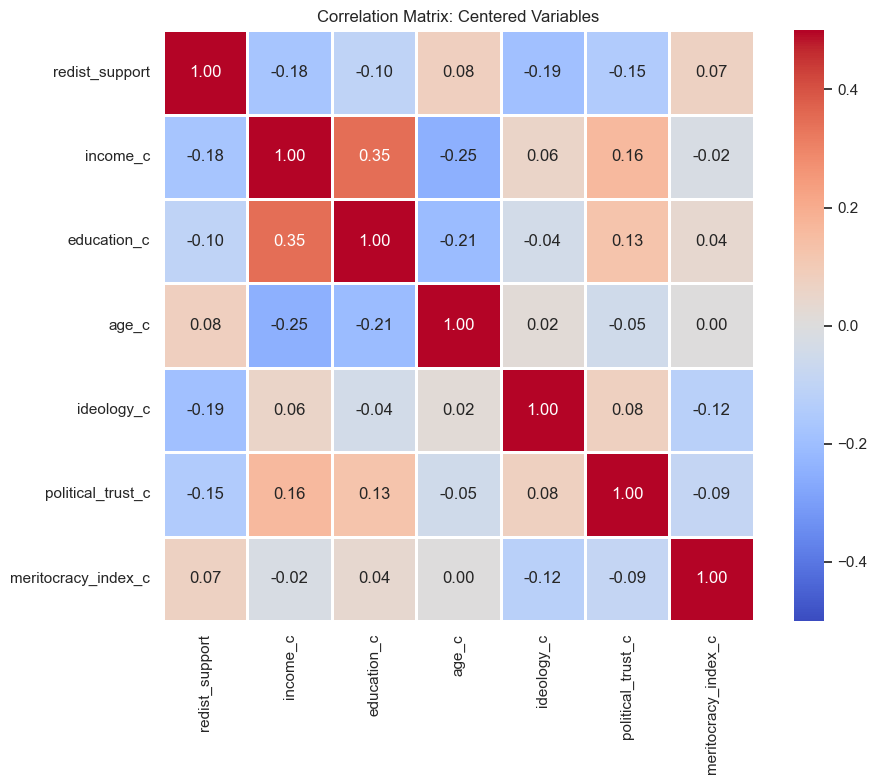

In [28]:
# Correlation matrix (transformed variables)
corr_vars = ['redist_support'] + level1_continuous
corr_vars = [v for v in corr_vars if v in df.columns]
corr_matrix = df[corr_vars].corr()

print("Correlation matrix (transformed variables):")
print(corr_matrix.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            square=True, linewidths=1)
ax.set_title('Correlation Matrix: Centered Variables')
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '02_correlation_centered.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Export Analysis Dataset

In [29]:
# Save to processed data directory
output_path = config.PROCESSED_DATA_DIR / 'analysis_data.csv'
config.PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)

print(f"Analysis dataset exported to:")
print(f"  {output_path}")
print(f"\nDataset summary:")
print(f"  - Observations: {len(df):,}")
print(f"  - Variables: {len(df.columns)}")
print(f"  - Countries: {df['country'].nunique()}")
print(f"  - File size: {output_path.stat().st_size / 1024**2:.1f} MB")

Analysis dataset exported to:
  C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis\data\processed\analysis_data.csv

Dataset summary:
  - Observations: 48,436
  - Variables: 609
  - Countries: 28
  - File size: 73.6 MB


## Summary

### Transformations completed

1. **Recoding:** Outcome reverse-coded (higher = more support), gender and employment dummies created
2. **Meritocracy index:** Averaged from `sofrwrk` + `ppldsrv` (ESS9 Justice & Fairness module)
3. **Level-1 centering:** All continuous individual-level predictors grand-mean centered (verified mean ~ 0)
4. **Level-2 standardization:** All country-level predictors z-scored (verified mean ~ 0, SD ~ 1)
5. **Regime assignment:** Esping-Andersen 5-regime and VoC 4-type classifications
6. **Merging:** Individual ESS data merged with country-level economic, institutional, and AI indicators

### Data quality

- Missing data generally low (<5%); income (~19%) and ideology (~15%) higher
- Regime distribution balanced across typologies

### Next steps

Notebook 03: Replication analysis (7-model multilevel sequence)

In [30]:
print("Data preparation complete!")
print(f"\nAnalysis dataset saved: {output_path}")
print("\nReady for Notebook 03: Replication Analysis")

Data preparation complete!

Analysis dataset saved: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis\data\processed\analysis_data.csv

Ready for Notebook 03: Replication Analysis
